**Step 1: Setup and Data Preparation**

In [3]:
import numpy as np
import re
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available    :", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.20.0
GPU available    : False


In [5]:
with open('/content/LSTM DATA.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print("Total characters:", len(text))
print(text[:300])


Total characters: 748151
﻿The Project Gutenberg eBook of Pride and Prejudice
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg Lice


In [6]:
start_marker = "It is a truth universally acknowledged"
end_marker   = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = text.find(start_marker)
end_idx   = text.find(end_marker)

text = text[start_idx:end_idx]
print("After trimming:", len(text), "characters")


After trimming: 694471 characters


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean = clean_text(text)
words = clean.split()

print("Total words after cleaning:", len(words))
print("First 30 words:", words[:30])


Total words after cleaning: 123623
First 30 words: ['it', 'is', 'a', 'truth', 'universally', 'acknowledged', 'that', 'a', 'single', 'man', 'in', 'possession', 'of', 'a', 'good', 'fortune', 'must', 'be', 'in', 'want', 'of', 'a', 'wife', 'however', 'little', 'known', 'the', 'feelings', 'or', 'views']


**Step 2: Tokenization and Sequence Generation**

In [8]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([clean])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
token_list = tokenizer.texts_to_sequences([clean])[0]
print("Total tokens:", len(token_list))


Vocabulary size: 6301
Total tokens: 123623


In [9]:
SEQ_LENGTH = 10
input_sequences = []

for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i - SEQ_LENGTH : i + 1]
    input_sequences.append(seq)

input_sequences = np.array(input_sequences)
print("Sequence array shape:", input_sequences.shape)


Sequence array shape: (123613, 11)


In [10]:
X = input_sequences[:, :-1]    # first 9 words
y = input_sequences[:, -1]     # 10th word is the target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (111251, 10)
Test size : (12362, 10)


**Step 3: Building the LSTM Model**

In [11]:
EMBEDDING_DIM = 100
HIDDEN_UNITS  = 150

model = Sequential([
    Input(shape=(SEQ_LENGTH - 1,)),
    Embedding(input_dim=total_words, output_dim=EMBEDDING_DIM),
    LSTM(HIDDEN_UNITS, return_sequences=True),
    Dropout(0.2),
    LSTM(HIDDEN_UNITS),
    Dropout(0.2),
    Dense(total_words, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 9, 100)         │       630,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 9, 150)         │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6301)           │       951,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,912,751 (7.30 MB)

 Trainable params: 1,912,751 (7.30 MB)

 Non-trainable params: 0 (0.00 B)

**Step 4: Training the Model**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 72s 89ms/step - accuracy: 0.0424 - loss: 6.3846 - val_accuracy: 0.0594 - val_loss: 6.1436 - learning_rate: 0.0010
Epoch 2/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.0619 - loss: 5.9836 - val_accuracy: 0.0700 - val_loss: 5.9675 - learning_rate: 0.0010
Epoch 3/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.0781 - loss: 5.7628 - val_accuracy: 0.0848 - val_loss: 5.8439 - learning_rate: 0.0010
Epoch 4/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 85s 86ms/step - accuracy: 0.0968 - loss: 5.5648 - val_accuracy: 0.1004 - val_loss: 5.7249 - learning_rate: 0.0010
Epoch 5/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step - accuracy: 0.1096 - loss: 5.3883 - val_accuracy: 0.1105 - val_loss: 5.6369 - learning_rate: 0.0010
Epoch 6/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.1195 - loss: 5.2526 - val_accuracy: 0.1144 - val_loss: 5.5957 - learning_rate: 0.0010
Epoch 7/30
783/783 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.1254 - l

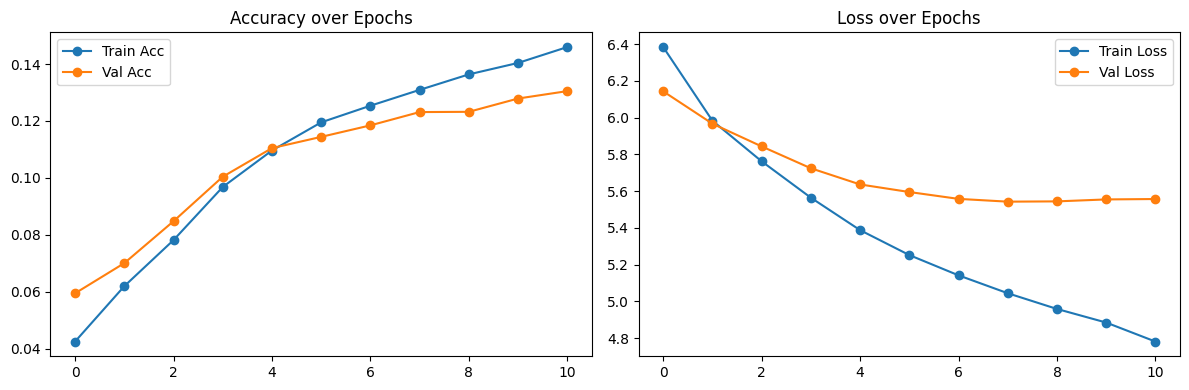

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Acc', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Acc', marker='o')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


**Step 5: Evaluating the Model**

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

Test Accuracy: 0.1193
Test Loss    : 5.5291


In [19]:
def predict_next_words(seed_text, next_words=10):
    output = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([output])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH-1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted)

        predicted_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                predicted_word = word
                break

        output += ' ' + predicted_word
    return output

prompts = [
    "it is a truth",
    "mr darcy was",
    "elizabeth could not",
    "she had been"
]

for prompt in prompts:
    result = predict_next_words(prompt, next_words=8)
    print(f"Seed   : '{prompt}'")
    print(f"Output : {result}\n")


Seed   : 'it is a truth'
Output : it is a truth to be sure he was not a very

Seed   : 'mr darcy was'
Output : mr darcy was not a very room and the whole of

Seed   : 'elizabeth could not'
Output : elizabeth could not be so much and i am sure i

Seed   : 'she had been'
Output : she had been to be a very room and the whole



In [20]:
def top_k_predictions(seed_text, k=5):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)[0]

    top_indices = predicted.argsort()[-k:][::-1]
    index_to_word = {v: k for k, v in tokenizer.word_index.items()}

    print(f"Prompt: '{seed_text}'")
    for idx in top_indices:
        word = index_to_word.get(idx, '<UNK>')
        prob = predicted[idx]
        print(f"  {word:15s} → {prob:.4f}")

top_k_predictions("it is a truth")
top_k_predictions("mr darcy was")


Prompt: 'it is a truth'
  to              → 0.1704
  and             → 0.0683
  of              → 0.0677
  for             → 0.0402
  with            → 0.0365
Prompt: 'mr darcy was'
  not             → 0.0511
  a               → 0.0293
  to              → 0.0232
  the             → 0.0201
  so              → 0.0139
